In [ ]:
!pip install kaggle
!kaggle datasets download -d sananmuzaffarov/european-football-injuries-2020-2025
!unzip european-football-injuries-2020-2025.zip


Dataset URL: https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025
License(s): CC-BY-SA-4.0
100% 287k/287k [00:00<00:00, 360kB/s]

Archive:  european-football-injuries-2020-2025.zip
  inflating: full_dataset_thesis - 1.csv  


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('full_dataset_thesis - 1.csv')

# Basic Labeling/Exploring
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nColumns: {df.columns.tolist()}")

#print(df.head())
# Check for the injurt description column
print(f"\nSample injury types: ")
print(df['Injury'].head(20))

# Convert dates to datetime
df['injury_start'] = pd.to_datetime(df['injury_from_parsed'])
df['injury_end'] = pd.to_datetime(df['injury_until_parsed'])

# Calculate duration
df['days_missed'] = (df['injury_end'] - df['injury_start']).dt.days

# Remove invalid entries
df = df[df['days_missed'] >= 0] # negative days = error

# Output Data Stats
print(f"\nDays Missed statistics: ")
print(df['days_missed'].describe())


Total Records: 15603
Total Columns: 11

Columns: ['Season', 'Injury', 'Days', 'Games missed', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_age', 'player_position', 'club', 'league']

Sample injury types: 
0     Syndesmosis ligament tear
1                   Knee injury
2                  Corona virus
3                        bruise
4               Ligament injury
5                       Fitness
6            Torn muscle bundle
7              Hamstring injury
8             Torn muscle fiber
9              Hamstring injury
10                  minor knock
11                Calf problems
12                 Corona virus
13             Hamstring injury
14             Broken nose bone
15                         cold
16            Torn muscle fiber
17         Torn ankle ligaments
18                 Bruised ribs
19               Thigh problems
Name: Injury, dtype: object

Days Missed statistics: 
count    15603.000000
mean        35.102929
std         54.419842
min         

In [ ]:
from __future__ import print_function
def classify_severity(days):
  """
  Classify injury severity by days missed
  """
  if days < 7:
    return 'Minor'
  elif days < 21:
    return 'Short-Term'
  elif days < 60:
    return 'Medium-Term'
  elif days < 180:
    return 'Long-Term'
  else:
    return 'Season-Ending'

# Apply Classification
df['severity'] = df['days_missed'].apply(classify_severity)

# Convert to numeric labels for model
severity_mapping = {
    'Minor': 0,
    'Short-Term': 1,
    'Medium-Term': 2,
    'Long-Term': 3,
    'Season-Ending': 4
}
df['severity_'] = df['severity'].map(severity_mapping)

# Check class distribution
print("\nSeverity Distribution:")
print(df['severity'].value_counts())
print("\nClass percentages: ")
print(df['severity'].value_counts(normalize=True) * 100) # Class % Distribution represented w/ decimal


Severity Distribution:
severity
Short-Term       5777
Medium-Term      4613
Minor            2895
Long-Term        1825
Season-Ending     493
Name: count, dtype: int64

Class percentages: 
severity
Short-Term       37.024931
Medium-Term      29.564827
Minor            18.554124
Long-Term        11.696469
Season-Ending     3.159649
Name: proportion, dtype: float64


In [ ]:
# Assuming the injury column is named 'Injury'
# Adjust based on actual column name in your dataset

# Remove missing values
df = df[df['Injury'].notna()]

# Clean text (optional - BioBERT handles most cases well)
df['injury_text'] = df['Injury'].str.strip()

# Remove any extremely short descriptions (likely errors)
df = df[df['injury_text'].str.len() > 2]

print(f"\nFinal dataset size: {len(df)} records")
print(f"\nSample injury texts:")
for i, text in enumerate(df['injury_text'].head(10)):
    print(f"{i+1}. {text}")


Final dataset size: 15603 records

Sample injury texts:
1. Syndesmosis ligament tear
2. Knee injury
3. Corona virus
4. bruise
5. Ligament injury
6. Fitness
7. Torn muscle bundle
8. Hamstring injury
9. Torn muscle fiber
10. Hamstring injury


In [ ]:
# 1. Reload the data (or use a backup if you made one earlier)
df_full = pd.read_csv('full_dataset_thesis - 1.csv')

# 2. Identify the short ones BEFORE you filter the main dataframe
short_records = df_full[df_full['Injury'].fillna('').str.len() <= 2]
missing_records = df_full[df_full['Injury'].isna()]

# 3. Print them out to inspect
print("--- SHORT DESCRIPTIONS (0-3 chars) ---")
print(short_records['Injury'].unique())

print("\n--- SAMPLE OF DATA THAT WOULD BE REMOVED ---")
print(short_records[['Injury', 'player_name']].head(10))

--- SHORT DESCRIPTIONS (0-3 chars) ---
[]

--- SAMPLE OF DATA THAT WOULD BE REMOVED ---
Empty DataFrame
Columns: [Injury, player_name]
Index: []


In [ ]:
# Seperate Datast
# TRAIN / TEST / VALIDATION
# 80/10/10
from sklearn.model_selection import train_test_split

# Create feature and label arrays
X = df['injury_text'].values # Text input
y = df['severity_'].values # Numeric labels (0-4)

# First split: 80% train, 20% temp (10%val + 10%test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,      # 20% for val+test
    random_state=42,
    stratify=y    # Maintain class distribution
)

# Second split:
X_val, X_test, y_val, y_test = train_test_split(
     X_temp, y_temp,
    test_size=0.5,      # 50% of 20% for 10% of total
    random_state=42,
    stratify=y_temp     # Maintain class distribution
)


# Verify total percentages
total_samples = len(X)
print(f"Total Samples: {total_samples}")
print(f"Train Samples: {len(X_train)} samples ({len(X_train)/total_samples*100:.1f}%)")
print(f"Validation Samples: {len(X_val)} samples ({len(X_val)/total_samples*100:.1f}%)")
print(f"Test Samples: {len(X_test)} samples ({len(X_test)/total_samples*100:.1f}%)")

# Check class distribution in each split
print("\n" + "-"*60)
print("CLASS DISTRIBUTION ACROSS SPLITS")
print("="*60)

severity_names = ['Minor', 'Short-Term', 'Medium-Term', 'Long-Term', 'Season-Ending']

for split_name, split_labels in [('Training ', y_train), ('Validation ', y_val), ('Test ', y_test)]:
    print(f"\n{split_name} set distribution:")
    unique, counts = np.unique(split_labels, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"{severity_names[label]}: {count} samples ({count/len(split_labels)*100:5.1f}%)")



Total Samples: 15603
Train Samples: 12482 samples (80.0%)
Validation Samples: 1560 samples (10.0%)
Test Samples: 1561 samples (10.0%)

------------------------------------------------------------
CLASS DISTRIBUTION ACROSS SPLITS

Training  set distribution:
Minor: 2316 samples ( 18.6%)
Short-Term: 4622 samples ( 37.0%)
Medium-Term: 3690 samples ( 29.6%)
Long-Term: 1460 samples ( 11.7%)
Season-Ending: 394 samples (  3.2%)

Validation  set distribution:
Minor: 289 samples ( 18.5%)
Short-Term: 577 samples ( 37.0%)
Medium-Term: 461 samples ( 29.6%)
Long-Term: 183 samples ( 11.7%)
Season-Ending: 50 samples (  3.2%)

Test  set distribution:
Minor: 290 samples ( 18.6%)
Short-Term: 578 samples ( 37.0%)
Medium-Term: 462 samples ( 29.6%)
Long-Term: 182 samples ( 11.7%)
Season-Ending: 49 samples (  3.1%)


In [ ]:
# TOKENIZE for BioBERT
from transformers import AutoTokenizer

# Load BioBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-v1.1')

# Tokenize all splits
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization complete!")
print(f"Example tokenized injury:")
print(f"Text: {X_train[0]}")
print(f"Token IDs: {train_encodings['input_ids'][0][:20]}...")  # First 20 tokens



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenization complete!
Example tokenized injury:
Text: influenza
Token IDs: [101, 1107, 27206, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


In [ ]:
# CREATE DATASET CLASS

import torch

class InjuryDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = InjuryDataset(train_encodings, y_train)
val_dataset = InjuryDataset(val_encodings, y_val)
test_dataset = InjuryDataset(test_encodings, y_test)

In [ ]:
# Load BioBERT Model

from transformers import AutoModelForSequenceClassification

# Load for classification
model = AutoModelForSequenceClassification.from_pretrained(
    'dmis-lab/biobert-v1.1',
    num_labels=5, # 5 severity classes
    problem_type="single_label_classification"
)

# Debug
print(f'Model loaded: {model.__class__.__name__}')
print(f'Number of parameters: {model.num_parameters()}')

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: BertForSequenceClassification
Number of parameters: 108314117


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,     # Batch size
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",              # Evaluate on each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2                  # Keep best 2 checkpoints
)

In [ ]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate metrics (f1 score)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }



model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

In [ ]:
# Train the Model
from transformers import Trainer

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Start training
print("Start training...")
trainer.train()

print("\nTraining complete!")


Start training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.196796,1.159561,0.500641,0.485417,0.549210,0.500641
2,1.166645,1.146517,0.498718,0.482585,0.527904,0.498718
3,1.135161,1.136876,0.507692,0.495060,0.551508,0.507692


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!


In [ ]:
# EVALUATE RESULTS
# Test Set Evaluation

test_results = trainer.evaluate(test_dataset)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")


TEST SET RESULTS
eval_loss: 1.1543
eval_accuracy: 0.4888
eval_f1: 0.4737
eval_precision: 0.5241
eval_recall: 0.4888
eval_runtime: 1.4913
eval_samples_per_second: 1046.7590
eval_steps_per_second: 16.7640
epoch: 3.0000


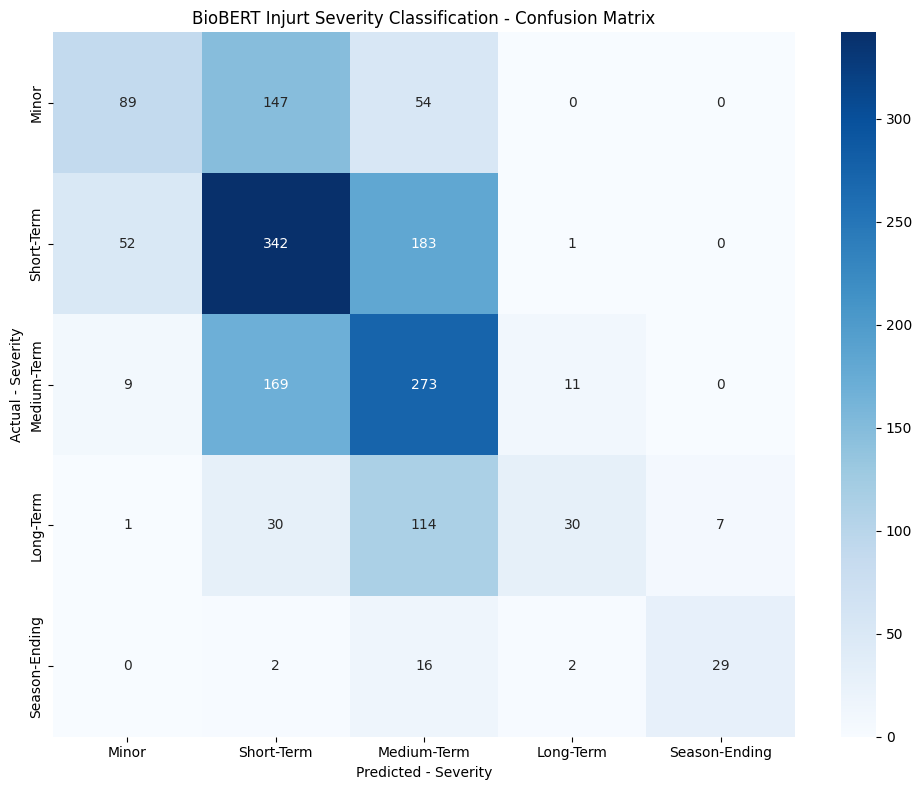


CLASSIFICATION REPORT
               precision    recall  f1-score   support

        Minor       0.59      0.31      0.40       290
   Short-Term       0.50      0.59      0.54       578
  Medium-Term       0.43      0.59      0.50       462
    Long-Term       0.68      0.16      0.27       182
Season-Ending       0.81      0.59      0.68        49

     accuracy                           0.49      1561
    macro avg       0.60      0.45      0.48      1561
 weighted avg       0.52      0.49      0.47      1561



In [ ]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=severity_names,
    yticklabels=severity_names
    )
plt.title('BioBERT Injurt Severity Classification - Confusion Matrix')
plt.xlabel('Predicted - Severity')
plt.ylabel('Actual - Severity')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=severity_names))

In [ ]:
# ERROR ANALYSIS

# Find misclassified examples
errors = []
for i, (true, pred) in enumerate(zip(y_test, y_pred)):
    if true != pred:
        errors.append({
            'text': X_test[i],
            'true_label': list(severity_mapping.keys())[true],
            'predicted_label': list(severity_mapping.keys())[pred],
            'days_missed': df.iloc[i]['days_missed']
        })
# Show 10 worst errors
print("\n" + "="*50)
print("SAMPLE MISCLASSIFICATIONS")
print("="*50)
for idx, error_data in enumerate(errors[:10]):
    print(f"\n{idx+1}. Injury: {error_data['text']}")
    print(f"   True: {error_data['true_label']} | Predicted: {error_data['predicted_label']}")


SAMPLE MISCLASSIFICATIONS

1. Injury: Ill
   True: Medium-Term | Predicted: Minor

2. Injury: Patellar tendon problems
   True: Long-Term | Predicted: Medium-Term

3. Injury: Ligament injury
   True: Minor | Predicted: Medium-Term

4. Injury: Back injury
   True: Long-Term | Predicted: Medium-Term

5. Injury: Calf injury
   True: Short-Term | Predicted: Medium-Term

6. Injury: Knee surgery
   True: Season-Ending | Predicted: Long-Term

7. Injury: Corona virus
   True: Medium-Term | Predicted: Short-Term

8. Injury: Ankle injury
   True: Short-Term | Predicted: Medium-Term

9. Injury: Ankle surgery
   True: Medium-Term | Predicted: Long-Term

10. Injury: muscular problems
   True: Minor | Predicted: Short-Term


In [ ]:
# Save the fine-tuned model
model.save_pretrained('./biobert_injury_classifier')
tokenizer.save_pretrained('./biobert_injury_classifier')

print("Model saved to './biobert_injury_classifier'")

# Save results to CSV
results_df = pd.DataFrame({
    'injury_text': X_test,
    'true_label': [list(severity_mapping.keys())[i] for i in y_test],
    'predicted_label': [list(severity_mapping.keys())[i] for i in y_pred]
})
results_df.to_csv('injury_classification_results.csv', index=False)

print("Results saved to 'injury_classification_results.csv'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './biobert_injury_classifier'
Results saved to 'injury_classification_results.csv'


In [ ]:
# TEST ON NEW INJURIES

def predict_severity(injury_text):
  """
  Predict severity for a new injury description
  """
  # Tokenize
  inputs = tokenizer(
      injury_text,
      return_tensors='pt',
      truncation=True,
      padding=True,
      max_length=128,
  )

  # Get the device of the model
  device = model.parameters().__next__().device

  # Move input tensors to the same device as the model
  inputs = {key: val.to(device) for key, val in inputs.items()}

  # Predict
  model.eval()
  with torch.no_grad():
    outputs = model(**inputs)
    prediction = outputs.logits.argmax(-1).item()

  # Get severity name
  severity_name = list(severity_mapping.keys())[prediction]

  # Get confidence scores
  probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
  # Move probabilities back to CPU for easier printing/handling if needed
  probabilities = probabilities.cpu()

  return severity_name, probabilities

# Test examples
test_injuries = [
    "Hamstring Strain",
    "Anterior Ligament Rupture",
    "Minor Ankle Knock",
    "Fractured Metatarsal"
]

print("\n" + "="*50)
print("PREDICTIONS ON NEW INJURIES")
print("="*50)

for injury in test_injuries:
  severity, confidences = predict_severity(injury)
  print(f"\nInjury: {injury}")
  print(f"Predicted Severity: {severity}")
  print(f"Confidence Scores:")
  for name, prob in zip(severity_names, confidences):
    print(f"{name}: {prob:.2%}")


PREDICTIONS ON NEW INJURIES

Injury: Hamstring Strain
Predicted Severity: Medium-Term
Confidence Scores:
Minor: 7.84%
Short-Term: 40.14%
Medium-Term: 43.12%
Long-Term: 8.35%
Season-Ending: 0.55%

Injury: Anterior Ligament Rupture
Predicted Severity: Long-Term
Confidence Scores:
Minor: 0.37%
Short-Term: 1.52%
Medium-Term: 9.83%
Long-Term: 50.16%
Season-Ending: 38.12%

Injury: Minor Ankle Knock
Predicted Severity: Short-Term
Confidence Scores:
Minor: 19.68%
Short-Term: 44.57%
Medium-Term: 29.34%
Long-Term: 5.81%
Season-Ending: 0.60%

Injury: Fractured Metatarsal
Predicted Severity: Long-Term
Confidence Scores:
Minor: 1.37%
Short-Term: 5.10%
Medium-Term: 34.09%
Long-Term: 52.58%
Season-Ending: 6.86%
